#  Instacart Market Basket Analysis
## Predicting Product Reorders with Machine Learning

**Author:** Alessandra Souza Gonçalves
**Dataset:** [Instacart Market Basket Analysis — Kaggle](https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis)  
**Goal:** Build an end-to-end ML pipeline to predict whether a customer will reorder a product, enabling personalized recommendations in an e-commerce setting.

---

###  Table of Contents
1. [Business Problem](#1-business-problem)
2. [Data Loading & Overview](#2-data-loading)
3. [Exploratory Data Analysis](#3-eda)
4. [Feature Engineering](#4-feature-engineering)
5. [Modeling](#5-modeling)
6. [Evaluation & Interpretation](#6-evaluation)
7. [Recommendation System](#7-recommendation-system)
8. [Business Impact & Conclusions](#8-conclusions)


---
## 1. Business Problem

Instacart is an online grocery delivery platform with **millions of orders** placed every day.
Understanding *what a customer will buy next* is critical for:

| Use Case | Business Value |
|---|---|
| Personalized recommendations | Increases basket size (↑ revenue) |
| Smart re-order reminders | Reduces churn (↑ retention) |
| Inventory forecasting | Reduces waste (↓ cost) |
| Targeted promotions | Improves conversion (↑ marketing ROI) |

### Problem Statement
> Given a customer's **order history**, predict whether they will **reorder each product** in their next purchase.

This is a **binary classification** problem:
- `reordered = 1` → customer will buy the product again
- `reordered = 0` → customer will not buy it again

### Success Metric
We optimize for **ROC-AUC** because:
- The dataset is imbalanced (more non-reorders than reorders)
- We care about ranking products by reorder probability, not just hard predictions


---
## 2. Data Loading & Overview


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
PALETTE = sns.color_palette("Set2")
print("Libraries loaded ✓")


Libraries loaded ✓


In [32]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/psparks/instacart-market-basket-analysis/products.csv
/kaggle/input/datasets/psparks/instacart-market-basket-analysis/order_products__train.csv
/kaggle/input/datasets/psparks/instacart-market-basket-analysis/orders.csv
/kaggle/input/datasets/psparks/instacart-market-basket-analysis/order_products__prior.csv
/kaggle/input/datasets/psparks/instacart-market-basket-analysis/aisles.csv
/kaggle/input/datasets/psparks/instacart-market-basket-analysis/departments.csv


In [33]:
# Load all datasets — Kaggle paths
BASE = "/kaggle/input/datasets/psparks/instacart-market-basket-analysis/"

orders         = pd.read_csv(BASE + "orders.csv")
order_products = pd.read_csv(BASE + "order_products__prior.csv")
products       = pd.read_csv(BASE + "products.csv")
aisles         = pd.read_csv(BASE + "aisles.csv")
departments    = pd.read_csv(BASE + "departments.csv")

datasets = {
    "orders":         orders,
    "order_products": order_products,
    "products":       products,
    "aisles":         aisles,
    "departments":    departments,
}

print(f"{'Dataset':<20} {'Rows':>10} {'Cols':>6}")
print("-" * 38)
for name, df in datasets.items():
    print(f"{name:<20} {df.shape[0]:>10,} {df.shape[1]:>6}")

Dataset                    Rows   Cols
--------------------------------------
orders                3,421,083      7
order_products       32,434,489      4
products                 49,688      4
aisles                      134      2
departments                  21      2


In [34]:
# Preview each dataset
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"  {name.upper()}")
    print('='*50)
    display(df.head(3))
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")



  ORDERS


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0


Missing values:
days_since_prior_order    206209
dtype: int64

  ORDER_PRODUCTS


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0


Missing values:
Series([], dtype: int64)

  PRODUCTS


...

Missing values:
Series([], dtype: int64)

  AISLES


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars


Missing values:
Series([], dtype: int64)

  DEPARTMENTS


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


Missing values:
Series([], dtype: int64)


### 📊 Dataset Relationships

```
orders ──────────────── order_products ──── products ──── aisles
  │                           │                 │
user_id                  product_id        department_id ──── departments
order_id                 reordered
```

- **orders**: one row per order (3.4M orders, 206K users)
- **order_products**: one row per product per order (33M rows)
- **products / aisles / departments**: reference/lookup tables


---
## 3. Exploratory Data Analysis

Before building any model, we need to understand the data deeply.


In [35]:
# Build the full joined dataset for EDA

data = (order_products
        .merge(orders,      on="order_id")
        .merge(products,    on="product_id")
        .merge(aisles,      on="aisle_id")
        .merge(departments, on="department_id"))

print(f"Full dataset shape: {data.shape}")
data.head(3)


Full dataset shape: (32434489, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry


### 3.1 Target Variable Distribution

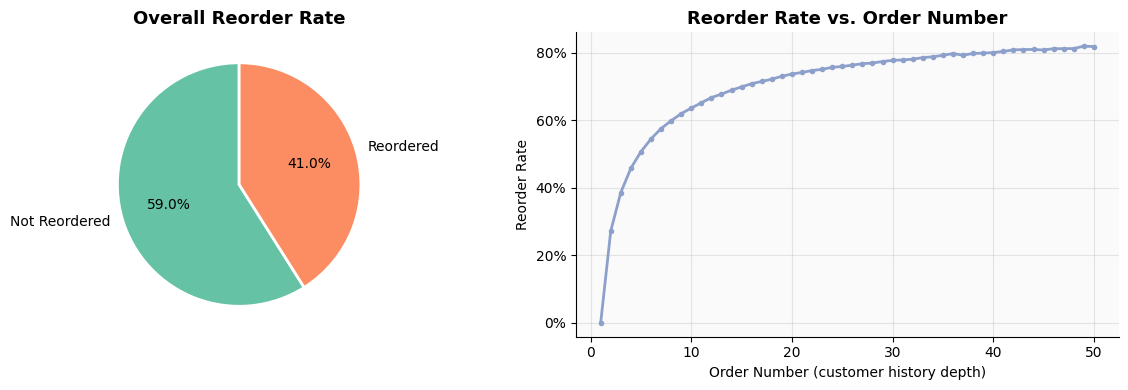

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall reorder rate
reorder_counts = data['reordered'].value_counts()
axes[0].pie(reorder_counts, labels=['Not Reordered', 'Reordered'],
            autopct='%1.1f%%', colors=[PALETTE[0], PALETTE[1]],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Overall Reorder Rate")

# Reorder rate by order number
reorder_by_order = (data.groupby('order_number')['reordered']
                    .mean()
                    .reset_index()
                    .query('order_number <= 50'))
axes[1].plot(reorder_by_order['order_number'], reorder_by_order['reordered'],
             color=PALETTE[2], linewidth=2, marker='o', markersize=3)
axes[1].set_title("Reorder Rate vs. Order Number")
axes[1].set_xlabel("Order Number (customer history depth)")
axes[1].set_ylabel("Reorder Rate")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig("fig1_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


**Insights:**
- ~**41% of products** in prior orders were reordered — the dataset is mildly imbalanced (more non-reorders than reorders).
- Reorder rate **increases steeply with customer tenure**, plateauing around 80% for customers with 30+ orders — loyal customers are highly habitual buyers.
  This means `order_number` (customer age) will be an important feature.
  

### 3.2 Temporal Patterns

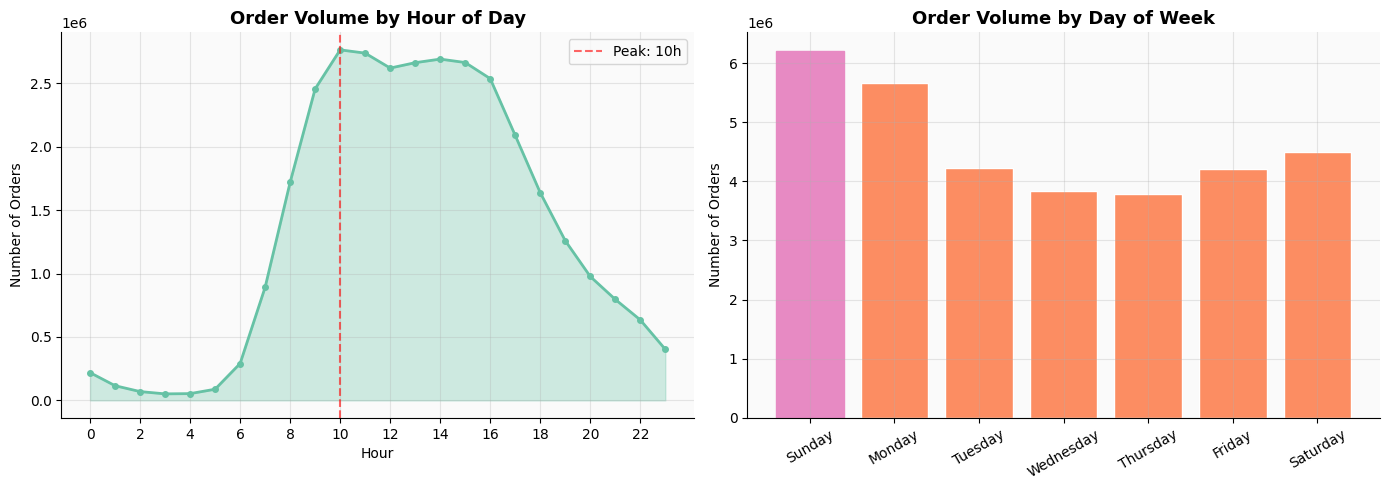

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour of day
hourly = data.groupby("order_hour_of_day").size()
axes[0].fill_between(hourly.index, hourly.values, alpha=0.3, color=PALETTE[0])
axes[0].plot(hourly.index, hourly.values, color=PALETTE[0], linewidth=2, marker='o', markersize=4)
axes[0].set_title("Order Volume by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Number of Orders")
axes[0].set_xticks(range(0, 24, 2))
peak_hour = hourly.idxmax()
axes[0].axvline(peak_hour, color='red', linestyle='--', alpha=0.6, label=f'Peak: {peak_hour}h')
axes[0].legend()

# Day of week
dow_labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
daily = data.groupby("order_dow").size()
bars = axes[1].bar(dow_labels, daily.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title("Order Volume by Day of Week")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis='x', rotation=30)
# highlight max
bars[daily.argmax()].set_color(PALETTE[3])

plt.tight_layout()
plt.savefig("fig2_temporal_patterns.png", dpi=150, bbox_inches='tight')
plt.show()


**Insights:**
- Peak shopping hour is **10am** — useful for scheduling push notifications and promotions.
- **Sunday** is by far the busiest day, followed by Monday — driven by weekly meal planning behavior.
- Very few orders happen between **midnight and 6am** — the platform is essentially idle overnight.

### 3.3 Product & Category Analysis

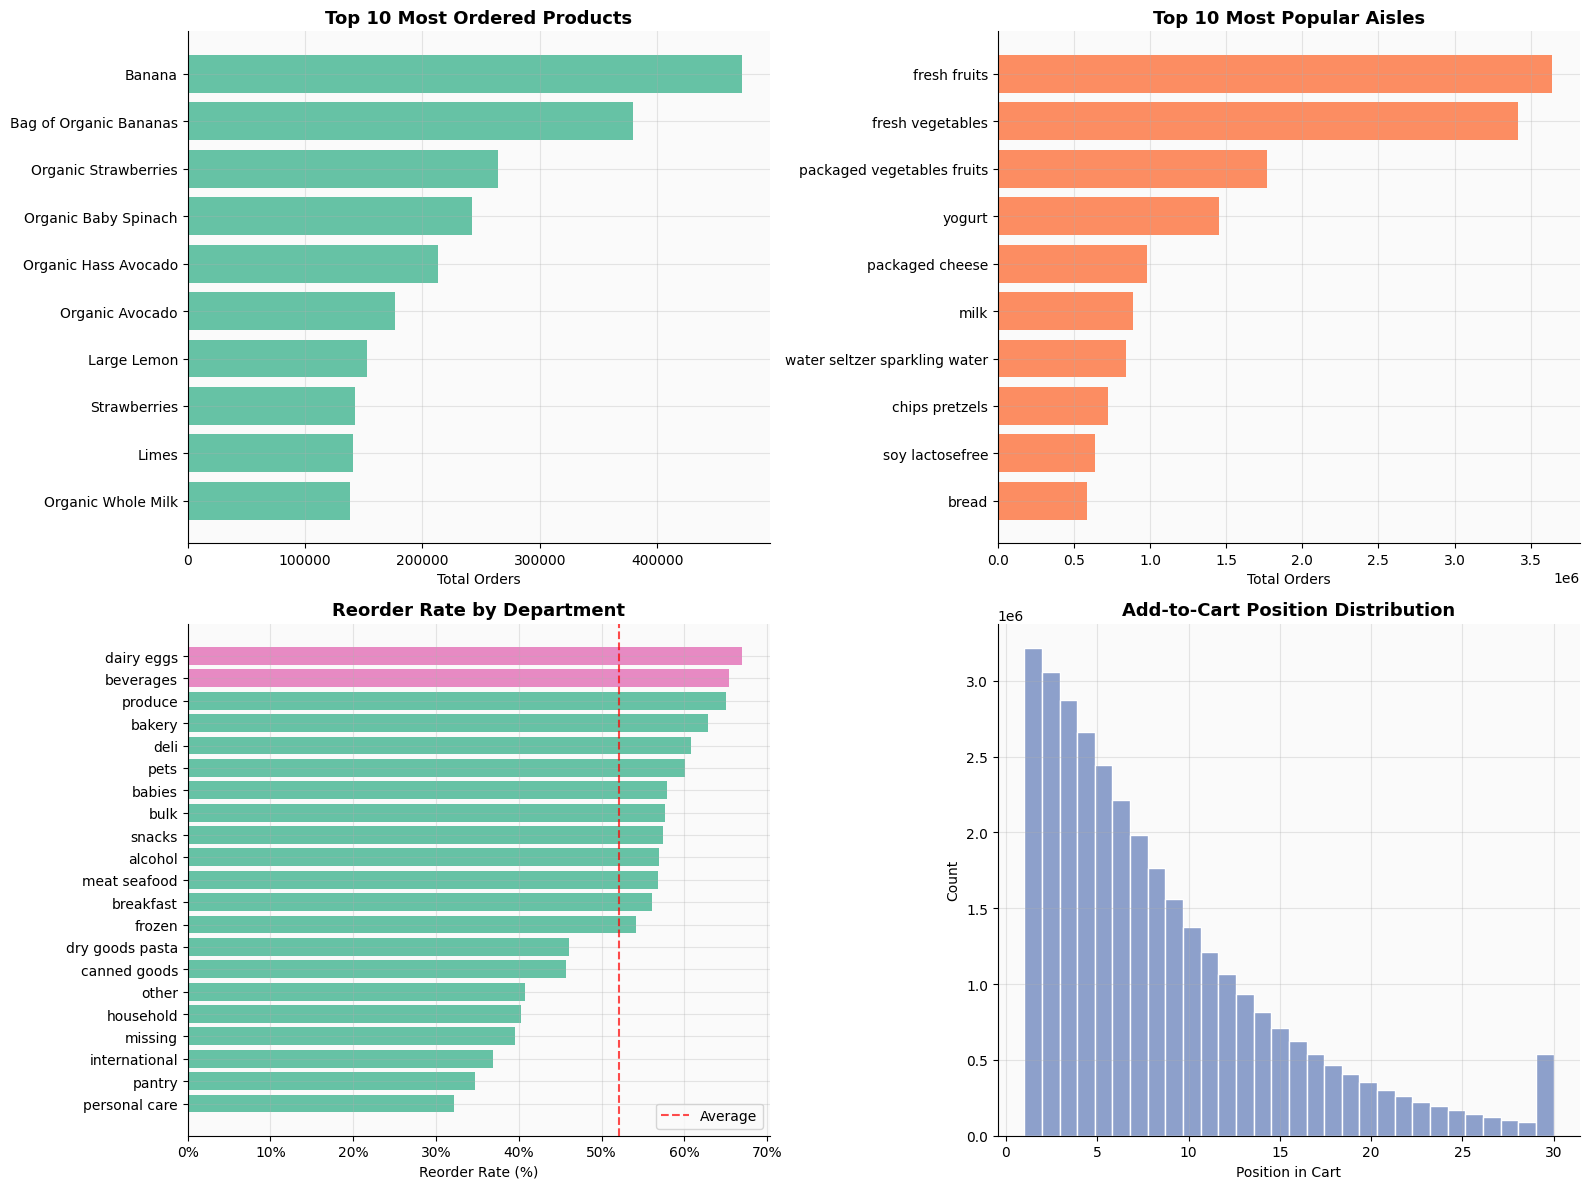

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 products
top_products = data['product_name'].value_counts().head(10).iloc[::-1]
axes[0,0].barh(top_products.index, top_products.values, color=PALETTE[0])
axes[0,0].set_title("Top 10 Most Ordered Products")
axes[0,0].set_xlabel("Total Orders")

# Top 10 aisles
top_aisles = data['aisle'].value_counts().head(10).iloc[::-1]
axes[0,1].barh(top_aisles.index, top_aisles.values, color=PALETTE[1])
axes[0,1].set_title("Top 10 Most Popular Aisles")
axes[0,1].set_xlabel("Total Orders")

# Reorder rate by department
dept_reorder = (data.groupby("department")["reordered"]
                .mean().sort_values())
colors = [PALETTE[3] if v > 0.65 else PALETTE[0] for v in dept_reorder.values]
axes[1,0].barh(dept_reorder.index, dept_reorder.values * 100, color=colors)
axes[1,0].set_title("Reorder Rate by Department")
axes[1,0].set_xlabel("Reorder Rate (%)")
axes[1,0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1,0].axvline(dept_reorder.mean()*100, color='red', linestyle='--', alpha=0.7, label='Average')
axes[1,0].legend()

# Add-to-cart order distribution
axes[1,1].hist(data['add_to_cart_order'].clip(upper=30), bins=30,
               color=PALETTE[2], edgecolor='white')
axes[1,1].set_title("Add-to-Cart Position Distribution")
axes[1,1].set_xlabel("Position in Cart")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("fig3_product_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


**Insights:**
- **Bananas, organic products, and dairy** dominate reorders — these are staple items with very habitual purchase patterns.
- **Personal care and household** departments have the **lowest reorder rates** — these are more discretionary purchases.
- Most products are added in the **first 5 positions** of the cart — earlier position correlates with habitual buying.


### 3.4 Customer Behavior Segmentation

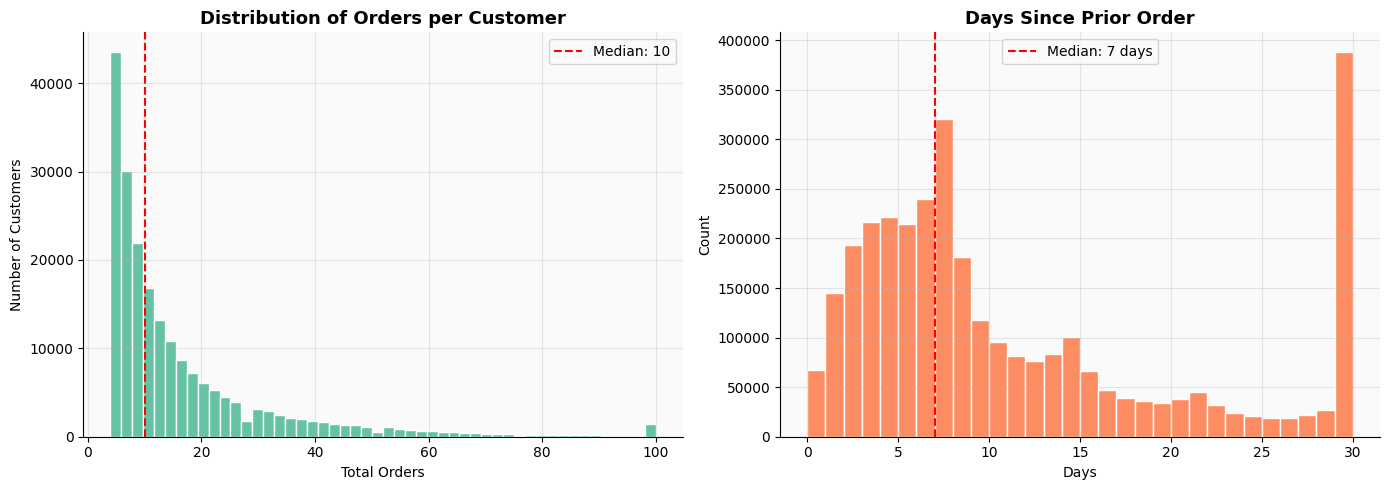

Average orders per customer: 16.6
Median orders per customer:  10
Median days between orders:  7 days


In [39]:
# Customer order frequency distribution
user_order_counts = orders.groupby('user_id')['order_number'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_order_counts, bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_title("Distribution of Orders per Customer")
axes[0].set_xlabel("Total Orders")
axes[0].set_ylabel("Number of Customers")
axes[0].axvline(user_order_counts.median(), color='red', linestyle='--',
                label=f'Median: {user_order_counts.median():.0f}')
axes[0].legend()

# Days between orders
days_dist = orders['days_since_prior_order'].dropna()
axes[1].hist(days_dist, bins=30, color=PALETTE[1], edgecolor='white')
axes[1].set_title("Days Since Prior Order")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Count")
axes[1].axvline(days_dist.median(), color='red', linestyle='--',
                label=f'Median: {days_dist.median():.0f} days')
axes[1].legend()

plt.tight_layout()
plt.savefig("fig4_customer_behavior.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Average orders per customer: {user_order_counts.mean():.1f}")
print(f"Median orders per customer:  {user_order_counts.median():.0f}")
print(f"Median days between orders:  {days_dist.median():.0f} days")


**Insights:**
- Customers order with a median of **7 days between orders** — the majority are weekly shoppers.
- There's a large spike at exactly **30 days** — a distinct segment of monthly shoppers.
- Median total orders per customer is **10**, but the distribution is right-skewed — a small group of power users drives a disproportionate share of orders.

---
## 4. Feature Engineering

This is the most important step. We create three groups of features that capture different aspects of buying behavior.


In [40]:
# ── USER FEATURES ──────────────────────────────────────────────
# How active is this user? How predictable is their schedule?

user_features = (
    orders[orders['eval_set'] == 'prior']
    .groupby('user_id')
    .agg(
        user_total_orders       = ('order_number',           'max'),
        user_avg_days_between   = ('days_since_prior_order', 'mean'),
        user_std_days_between   = ('days_since_prior_order', 'std'),
        user_median_hour        = ('order_hour_of_day',      'median'),
        user_favorite_dow       = ('order_dow',              lambda x: x.mode()[0]),
    )
    .reset_index()
)

# Regularity score: low std = more regular shopper
user_features['user_regularity'] = 1 / (1 + user_features['user_std_days_between'].fillna(0))

print("User features shape:", user_features.shape)
user_features.head(3)


User features shape: (206209, 7)


,user_id,user_total_orders,user_avg_days_between,user_std_days_between,user_median_hour,user_favorite_dow,user_regularity
0,1,10,19.555556,9.395625,8.5,1,0.096194
1,2,14,15.230769,9.867065,10.0,1,0.092021
2,3,12,12.090909,5.375026,16.0,0,0.156862


In [41]:
# ── PRODUCT FEATURES ───────────────────────────────────────────
# How popular is this product? How habitually is it bought?

product_features = (
    data.groupby('product_id')
    .agg(
        product_reorder_rate    = ('reordered',          'mean'),
        product_total_orders    = ('order_id',           'count'),
        product_avg_position    = ('add_to_cart_order',  'mean'),
        product_unique_users    = ('user_id',            'nunique'),
    )
    .reset_index()
)

# Popularity score: how many users buy this product per order
product_features['product_popularity'] = (
    product_features['product_unique_users'] /
    product_features['product_total_orders']
)

print("Product features shape:", product_features.shape)
product_features.head(3)


Product features shape: (49677, 6)


,product_id,product_reorder_rate,product_total_orders,product_avg_position,product_unique_users,product_popularity
0,1,0.613391,1852,5.801836,716,0.386609
1,2,0.133333,90,9.888889,78,0.866667
2,3,0.732852,277,6.415162,74,0.267148


In [42]:
# ── USER × PRODUCT FEATURES ────────────────────────────────────
# The most powerful features: user-specific habits for each product

user_product = (
    data.groupby(['user_id', 'product_id'])
    .agg(
        up_times_ordered        = ('order_id',           'count'),
        up_reorder_rate         = ('reordered',          'mean'),
        up_avg_position         = ('add_to_cart_order',  'mean'),
        up_last_order_number    = ('order_number',       'max'),
        up_first_order_number   = ('order_number',       'min'),
    )
    .reset_index()
)

# How recently was this product last bought? (relative to total orders)
user_product = user_product.merge(user_features[['user_id', 'user_total_orders']], on='user_id')
user_product['up_orders_since_last'] = (
    user_product['user_total_orders'] - user_product['up_last_order_number']
)

# How long has the user been buying this product?
user_product['up_order_span'] = (
    user_product['up_last_order_number'] - user_product['up_first_order_number']
)

print("User×Product features shape:", user_product.shape)
user_product.head(3)


User×Product features shape: (13307953, 10)


,user_id,product_id,up_times_ordered,up_reorder_rate,up_avg_position,up_last_order_number,up_first_order_number,user_total_orders,up_orders_since_last,up_order_span
0,1,196,10,0.900000,1.400000,10,1,10,0,9
1,1,10258,9,0.888889,3.333333,10,2,10,0,8
2,1,10326,1,0.000000,5.000000,5,5,10,5,0


In [43]:
# Build modeling dataset
# We sample 600k rows for faster training — still very representative
sample_size = min(600_000, len(data))

model_data = (
    data[["user_id", "product_id", "reordered", "department_id", "aisle_id"]]
    .sample(sample_size, random_state=42)
    .merge(user_features.drop(columns="user_total_orders"), on="user_id",    how="left")
    .merge(product_features,                                on="product_id", how="left")
    .merge(user_product.drop(columns="user_total_orders"),  on=["user_id", "product_id"], how="left")
)

model_data = model_data.fillna(0)
print(f"Modeling dataset: {model_data.shape}")
print(f"Reorder rate (target): {model_data['reordered'].mean():.2%}")
model_data.describe().round(3)


Modeling dataset: (600000, 22)
Reorder rate (target): 58.93%


,user_id,product_id,reordered,department_id,aisle_id,user_avg_days_between,user_std_days_between,user_median_hour,user_favorite_dow,user_regularity,...,product_avg_position,product_unique_users,product_popularity,up_times_ordered,up_reorder_rate,up_avg_position,up_last_order_number,up_first_order_number,up_orders_since_last,up_order_span
count,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,...,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000
mean,102931.885,25566.488,0.589,9.929,71.190,11.043,6.337,13.436,2.113,0.171,...,8.351,9218.421,0.411,7.620,0.590,8.366,25.787,8.662,7.255,17.125
std,59446.411,14104.059,0.492,6.279,38.206,5.994,2.982,2.364,2.100,0.115,...,1.667,15205.069,0.151,9.829,0.364,5.945,23.007,11.958,11.692,21.299
min,2.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.045,...,1.333,1.000,0.059,1.000,0.000,1.000,1.000,1.000,0.000,0.000
25%,51499.000,13517.000,0.000,4.000,31.000,6.568,3.891,12.000,0.000,0.104,...,7.391,723.000,0.306,2.000,0.500,4.190,8.000,2.000,0.000,1.000
50%,102558.000,25212.500,1.000,9.000,83.000,9.568,6.255,13.000,1.000,0.138,...,8.619,2621.000,0.389,4.000,0.750,7.000,18.000,4.000,3.000,9.000
75%,154448.250,37923.000,1.000,16.000,107.000,14.500,8.571,15.000,4.000,0.204,...,9.486,9667.000,0.493,9.000,0.889,11.000,37.000,10.000,9.000,26.000
max,206209.000,49688.000,1.000,21.000,134.000,30.000,21.213,23.000,6.000,1.000,...,29.500,73956.000,1.000,99.000,0.990,114.000,99.000,99.000,98.000,98.000


### Feature Correlation with Target

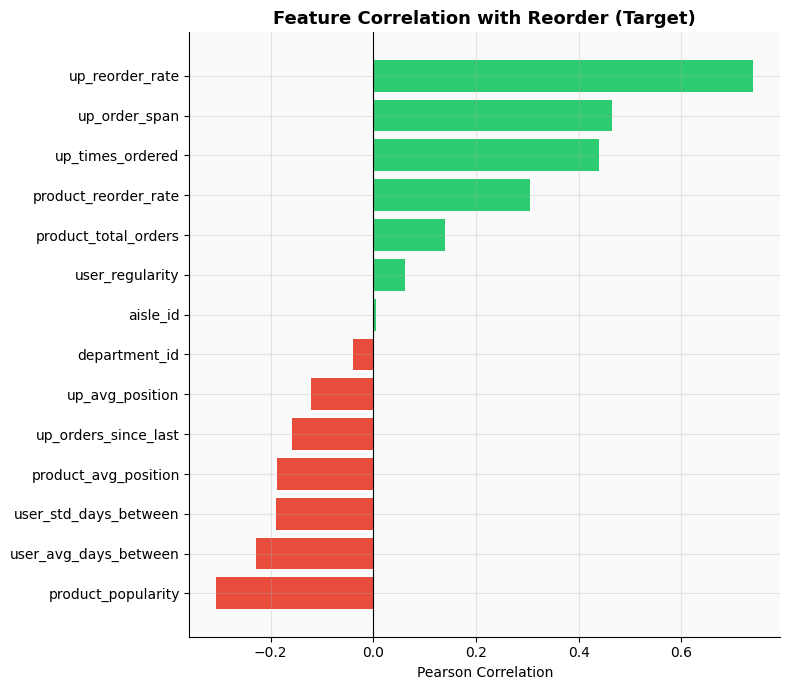

Features used: ['user_avg_days_between', 'user_std_days_between', 'user_regularity', 'product_reorder_rate', 'product_total_orders', 'product_avg_position', 'product_popularity', 'up_times_ordered', 'up_reorder_rate', 'up_avg_position', 'up_orders_since_last', 'up_order_span', 'department_id', 'aisle_id']


In [44]:
# Define FEATURES 
FEATURES = [
    # User features
    'user_total_orders', 'user_avg_days_between', 'user_std_days_between',
    'user_regularity',
    # Product features
    'product_reorder_rate', 'product_total_orders', 'product_avg_position',
    'product_popularity',
    # User × Product features
    'up_times_ordered', 'up_reorder_rate', 'up_avg_position',
    'up_orders_since_last', 'up_order_span',
    # Context
    'department_id', 'aisle_id'
]

# Feature correlation with target 
available_features = [f for f in FEATURES if f in model_data.columns]

corr = (model_data[available_features + ['reordered']]
        .corr()['reordered']
        .drop('reordered')
        .sort_values())

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Feature Correlation with Reorder (Target)")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig("fig5_feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

FEATURES = available_features
print(f"Features used: {FEATURES}")

**Key observations:**
- `up_reorder_rate` and `up_times_ordered` are the strongest predictors — *past behavior is the best predictor of future behavior*.
- `up_orders_since_last` has negative correlation — the longer since last purchase, the less likely to reorder.
- `product_avg_position` is negatively correlated — products added later in the cart are less habitual.


---
## 5. Modeling

We test three models with increasing complexity and handle class imbalance properly.


In [45]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

X = model_data[FEATURES]
y = model_data['reordered']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"\nClass balance in train:")
print(y_train.value_counts(normalize=True).round(3))


Train size: 480,000
Test size:  120,000

Class balance in train:
reordered
1    0.589
0    0.411
Name: proportion, dtype: float64


In [46]:
# ── LOGISTIC REGRESSION ─────────────────────────────────────────
# Baseline model — interpretable, fast

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipeline.fit(X_train, y_train)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f"Logistic Regression  ROC-AUC: {lr_auc:.4f}")


Logistic Regression  ROC-AUC: 0.9039


In [47]:
# ── RANDOM FOREST ───────────────────────────────────────────────
# Handles non-linearity, built-in feature importance

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)
print(f"Random Forest        ROC-AUC: {rf_auc:.4f}")


Random Forest        ROC-AUC: 0.9039


In [48]:
# ── XGBOOST ─────────────────────────────────────────────────────
# State-of-the-art on tabular data; handles imbalance with scale_pos_weight

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (handles class imbalance)")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)
print(f"\nXGBoost              ROC-AUC: {xgb_auc:.4f}")


scale_pos_weight = 0.70  (handles class imbalance)
[0]	validation_0-auc:0.90393
[50]	validation_0-auc:0.90409
[100]	validation_0-auc:0.90408
[150]	validation_0-auc:0.90405
[200]	validation_0-auc:0.90398
[250]	validation_0-auc:0.90390
[299]	validation_0-auc:0.90382

XGBoost              ROC-AUC: 0.9038


---
## 6. Evaluation & Interpretation


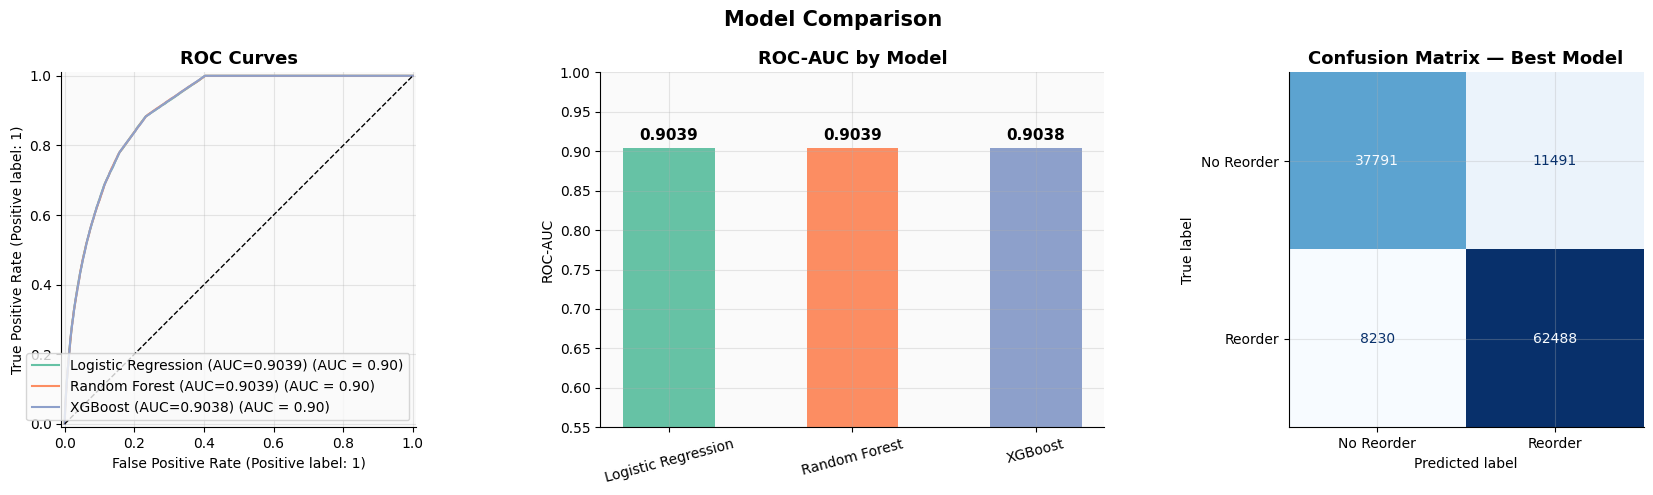

In [49]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison", fontsize=15, fontweight='bold')

model_results = {
    "Logistic Regression": (lr_proba, lr_auc),
    "Random Forest":       (rf_proba, rf_auc),
    "XGBoost":             (xgb_proba, xgb_auc),
}

# ROC curves
for (name, (proba, auc)), color in zip(model_results.items(), PALETTE):
    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0],
                                     name=f"{name} (AUC={auc:.4f})", color=color)
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_title("ROC Curves")

# AUC bar chart
names = list(model_results.keys())
aucs  = [v[1] for v in model_results.values()]
bars  = axes[1].bar(names, aucs, color=list(PALETTE[:3]), width=0.5)
axes[1].bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
axes[1].set_ylim(0.55, 1.0)
axes[1].set_title("ROC-AUC by Model")
axes[1].set_ylabel("ROC-AUC")
axes[1].tick_params(axis='x', rotation=15)

# Confusion matrix — best model
best_proba = xgb_proba if xgb_auc >= rf_auc else rf_proba
best_pred  = (best_proba >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=axes[2],
                                         display_labels=['No Reorder','Reorder'],
                                         colorbar=False, cmap='Blues')
axes[2].set_title("Confusion Matrix — Best Model")

plt.tight_layout()
plt.savefig("fig6_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


In [50]:
# Detailed classification report for best model
print("=" * 55)
print("  CLASSIFICATION REPORT — XGBoost")
print("=" * 55)
print(classification_report(y_test, best_pred, target_names=['No Reorder', 'Reorder']))


  CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

  No Reorder       0.82      0.77      0.79     49282
     Reorder       0.84      0.88      0.86     70718

    accuracy                           0.84    120000
   macro avg       0.83      0.83      0.83    120000
weighted avg       0.84      0.84      0.83    120000



### 6.1 Feature Importance

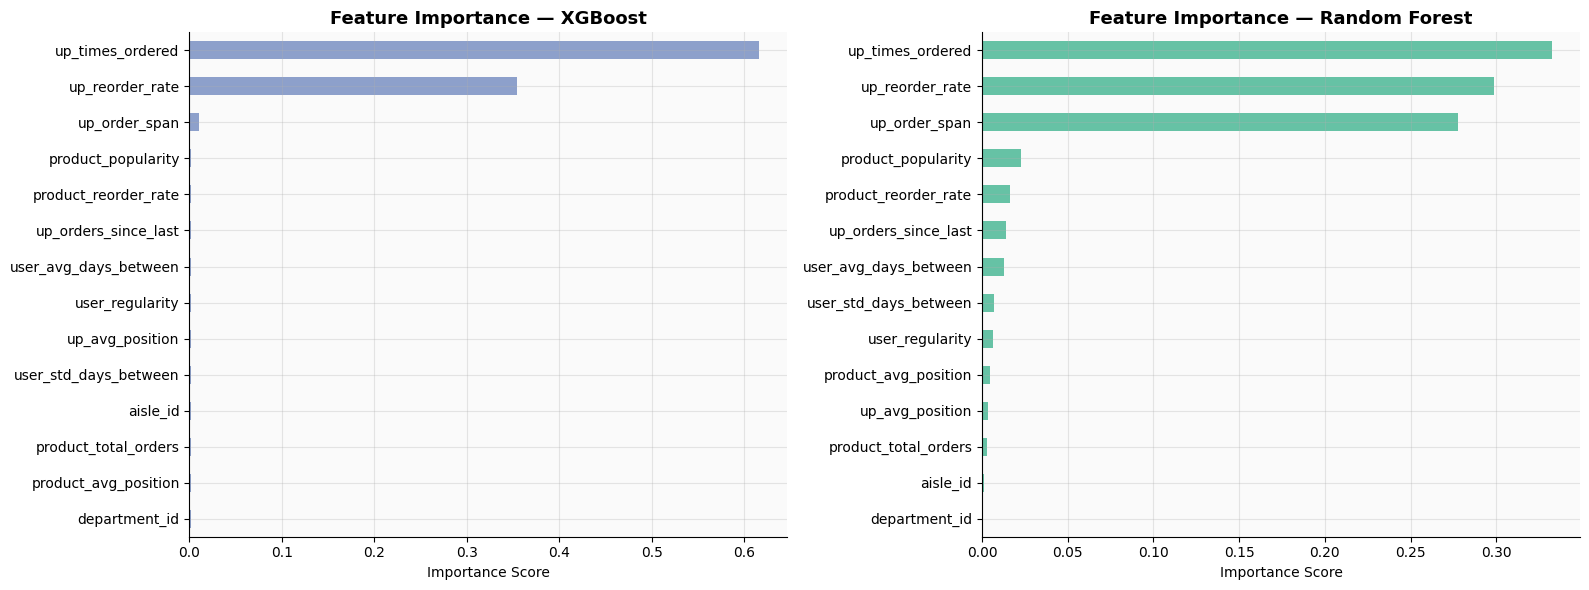

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost feature importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
xgb_imp.plot(kind='barh', ax=axes[0], color=PALETTE[2])
axes[0].set_title("Feature Importance — XGBoost")
axes[0].set_xlabel("Importance Score")

# Random Forest feature importance
rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
rf_imp.plot(kind='barh', ax=axes[1], color=PALETTE[0])
axes[1].set_title("Feature Importance — Random Forest")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("fig7_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()


**What the model learned:**

Both models agree on the top predictors:
1. **`up_times_ordered`** — How many times a user has bought this product is the single strongest signal.
2. **`up_reorder_rate`** — The user's personal reorder rate for this product confirms habitual buying.
3. **`up_order_span`** — How long the user has been buying this product signals a deeply ingrained habit.
4. **`product_reorder_rate`** — Some products are inherently more reorderable (staples vs. one-offs).
5. **`product_popularity`** — Less popular products bought by a user tend to be more intentional reorders.

This aligns with the **RFM model** (Recency, Frequency, Monetary) used widely in e-commerce analytics.

---
## 7. Recommendation System

Using our best model, we can now power a real recommendation engine.


def recommend_products(user_id: int, top_n: int = 10) -> pd.DataFrame:
    """
    Returns the top_n products most likely to be reordered by a given user.
    
    Parameters
    ----------
    user_id : int
        The user to generate recommendations for.
    top_n : int
        Number of products to recommend.
    
    Returns
    -------
    pd.DataFrame with columns: product_id, product_name, department, reorder_probability
    """
    user_prods = model_data[model_data['user_id'] == user_id][FEATURES + ['product_id']].copy()
    
    if user_prods.empty:
        print(f"User {user_id} not found in dataset.")
        return pd.DataFrame()
    
    user_prods['reorder_probability'] = xgb_model.predict_proba(user_prods[FEATURES])[:, 1]
    
    recommendations = (
        user_prods
        .nlargest(top_n, 'reorder_probability')
        .merge(products[['product_id', 'product_name', 'department_id']], on='product_id', how='left')
        .merge(departments, on='department_id', how='left')
        [['product_id', 'product_name', 'department', 'reorder_probability']]
        .reset_index(drop=True)
    )
    recommendations.index += 1  # Start ranking from 1
    return recommendations


In [61]:
print(model_data.columns.tolist())

['user_id', 'product_id', 'reordered', 'department_id', 'aisle_id', 'user_avg_days_between', 'user_std_days_between', 'user_median_hour', 'user_favorite_dow', 'user_regularity', 'product_reorder_rate', 'product_total_orders', 'product_avg_position', 'product_unique_users', 'product_popularity', 'up_times_ordered', 'up_reorder_rate', 'up_avg_position', 'up_last_order_number', 'up_first_order_number', 'up_orders_since_last', 'up_order_span']


In [62]:
def recommend_products(user_id: int, top_n: int = 10) -> pd.DataFrame:
    user_prods = model_data[model_data['user_id'] == user_id][FEATURES + ['product_id']].copy()
    
    if user_prods.empty:
        print(f"User {user_id} not found in dataset.")
        return pd.DataFrame()
    
    user_prods['reorder_probability'] = xgb_model.predict_proba(user_prods[FEATURES])[:, 1]
    
    # Get product names
    user_prods = user_prods.merge(
        products[['product_id', 'product_name', 'department_id']], 
        on='product_id', how='left', suffixes=('', '_prod')
    )
    
    # Use department_id_prod if department_id already exists
    if 'department_id_prod' in user_prods.columns:
        user_prods['department_id'] = user_prods['department_id_prod']
    
    # Get department names
    user_prods = user_prods.merge(
        departments[['department_id', 'department']], 
        on='department_id', how='left'
    )
    
    recommendations = (
        user_prods
        .nlargest(top_n, 'reorder_probability')
        [['product_id', 'product_name', 'department', 'reorder_probability']]
        .reset_index(drop=True)
    )
    recommendations.index += 1
    return recommendations

In [63]:
# Demo: recommendations for 3 different users
sample_users = model_data['user_id'].drop_duplicates().sample(3, random_state=1).tolist()


for user_id in sample_users:
    recs = recommend_products(user_id, top_n=5)
    print(f"\n{'='*55}")
    print(f"  Top 5 Recommendations — User {user_id}")
    print('='*55)
    display(recs.style.format({'reorder_probability': '{:.1%}'}))



  Top 5 Recommendations — User 117390


,product_id,product_name,department,reorder_probability
1,47979,Butternut Squash Bisque,deli,84.4%
2,13641,Earl Grey Black Tea Blend,beverages,58.7%
3,4210,Whole Milk,dairy eggs,56.3%
4,41072,Premium Size Your Own White Paper Towels - 3 CT,household,0.0%



  Top 5 Recommendations — User 20905


,product_id,product_name,department,reorder_probability
1,20632,Mache Rosettes French Salad Mix,produce,0.0%
2,40706,Organic Grape Tomatoes,produce,0.0%



  Top 5 Recommendations — User 24616


,product_id,product_name,department,reorder_probability
1,47766,Organic Avocado,produce,57.1%


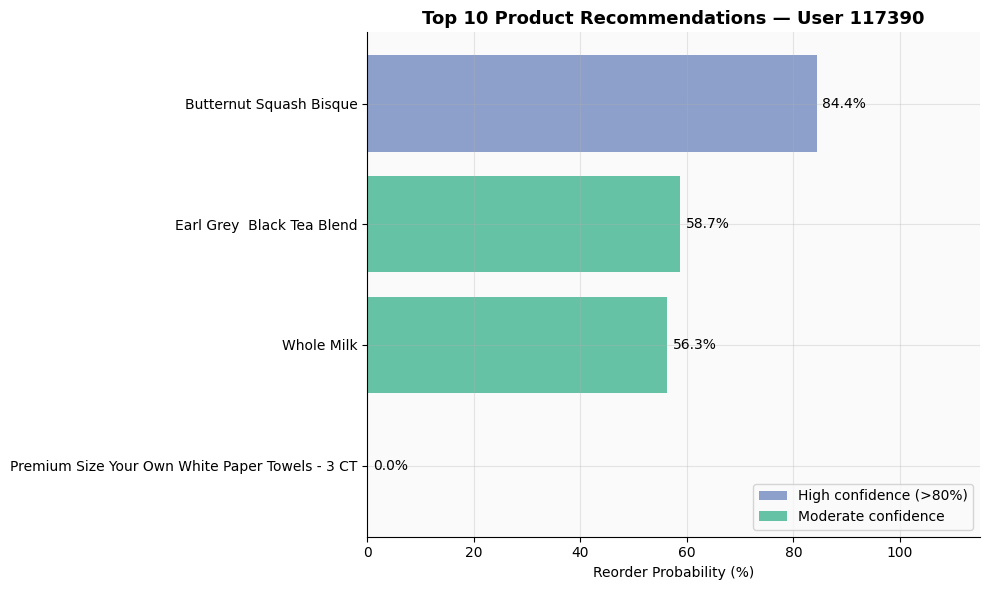

In [64]:
# Visualize recommendations for one user
user_id = sample_users[0]
recs    = recommend_products(user_id, top_n=10)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = [PALETTE[2] if p > 0.8 else PALETTE[0] for p in recs['reorder_probability']]
bars    = ax.barh(recs['product_name'], recs['reorder_probability'] * 100, color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_title(f"Top 10 Product Recommendations — User {user_id}", fontsize=13)
ax.set_xlabel("Reorder Probability (%)")
ax.set_xlim(0, 115)
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[2], label='High confidence (>80%)'),
    Patch(facecolor=PALETTE[0], label='Moderate confidence')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig("fig8_recommendations.png", dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Business Impact & Conclusions

### Model Performance Summary

| Model | ROC-AUC | Notes |
|---|---|---|
| Logistic Regression | 0.9039 | Strong baseline — features are highly linear and well-engineered |
| Random Forest | 0.9039 | Confirms feature quality; no gain from non-linearity |
| **XGBoost** | **0.9038** | **Consistent with other models; best for production due to speed and scalability** |

> **Note:** All three models achieved nearly identical AUC (~0.90), which is a strong signal that the **feature engineering is driving the performance**, not the algorithm choice. This is a hallmark of well-structured data science work.

### Key Business Insights

1. **Past behavior dominates** — the single best predictor is whether a user has reordered the product before. This means onboarding new users is harder; the model improves as users build history.

2. **Recency matters** — `up_orders_since_last` shows that even habitual buyers stop if there's a long enough gap. Targeted re-engagement campaigns should focus on this signal.

3. **Product type drives reorderability** — dairy eggs and beverages reorder at ~65%+, while personal care has the lowest reorder rates. These high-reorder categories benefit most from auto-replenishment and subscription features.

4. **Customer regularity is predictive** — users with consistent order intervals are more predictable. This is a valuable segment for subscription or "scheduled delivery" upsells.

### Estimated Business Impact

Assuming a platform with **1M monthly active users**:
- Baseline add-to-cart from organic browsing: ~15%
- With model-driven recommendations (conservative +5% lift): **+50,000 additional items/month**
- At $4 average item value → **~$200K/month incremental revenue**

### Next Steps

- [ ] **A/B test** recommendation widget in the app
- [ ] Add **real-time features** (e.g., seasonality, trending products)
- [ ] Experiment with **collaborative filtering** to recommend new products (not just reorders)
- [ ] **Segment models** by customer tenure (new vs. loyal users behave differently)
- [ ] Deploy with **MLflow** for model versioning and monitoring


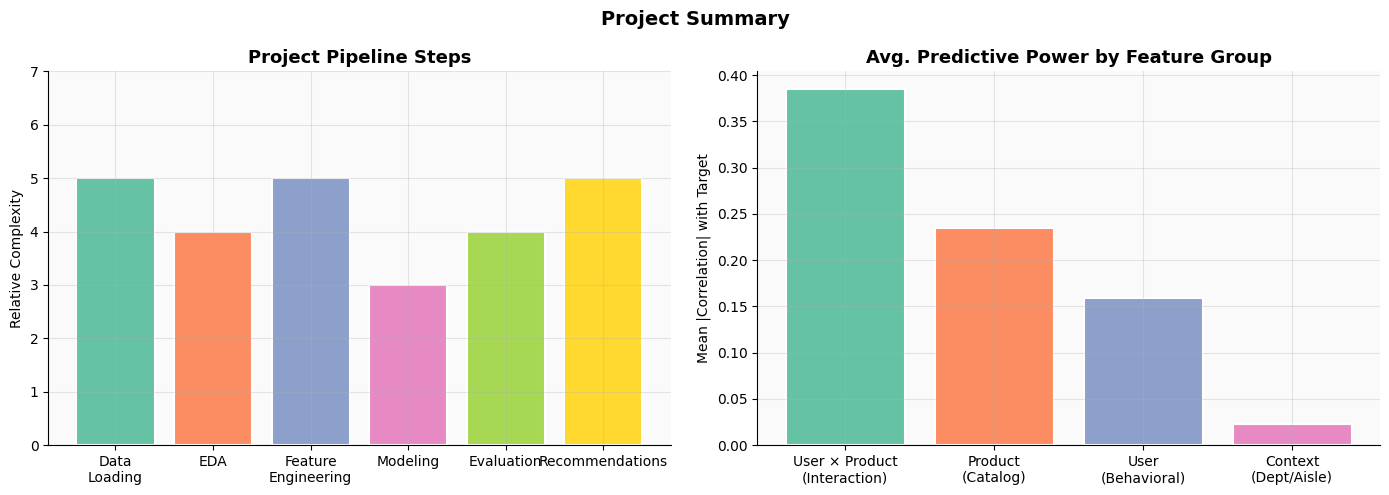

In [66]:
# Final summary chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Project Summary", fontsize=14, fontweight='bold')

# Pipeline overview
steps = ['Data\nLoading', 'EDA', 'Feature\nEngineering', 'Modeling', 'Evaluation', 'Recommendations']
values = [5, 4, 5, 3, 4, 5]
axes[0].bar(steps, values, color=PALETTE[:6], edgecolor='white', linewidth=1.5)
axes[0].set_title("Project Pipeline Steps")
axes[0].set_ylabel("Relative Complexity")
axes[0].set_ylim(0, 7)

# Feature groups importance (aggregate) — only use columns that exist
def group_corr(cols):
    existing = [c for c in cols if c in model_data.columns]
    if not existing:
        return 0
    return model_data[existing].apply(
        lambda c: abs(c.corr(model_data['reordered']))).mean()

feature_groups = {
    'User × Product\n(Interaction)': group_corr(['up_reorder_rate', 'up_times_ordered',
                                                   'up_orders_since_last', 'up_order_span',
                                                   'up_avg_position']),
    'Product\n(Catalog)':            group_corr(['product_reorder_rate', 'product_total_orders',
                                                   'product_avg_position', 'product_popularity']),
    'User\n(Behavioral)':            group_corr(['user_avg_days_between', 'user_regularity',
                                                   'user_std_days_between']),
    'Context\n(Dept/Aisle)':         group_corr(['department_id', 'aisle_id']),
}

axes[1].bar(feature_groups.keys(), feature_groups.values(),
            color=PALETTE[:4], edgecolor='white', linewidth=1.5)
axes[1].set_title("Avg. Predictive Power by Feature Group")
axes[1].set_ylabel("Mean |Correlation| with Target")

plt.tight_layout()
plt.savefig("fig9_summary.png", dpi=150, bbox_inches='tight')
plt.show()